# 01 — Exploration
**Goal:** get a first honest look at the two marts tables produced by dbt (`player_value_history`, `player_injury_workload`) before any modeling. We're checking: does the data actually support the hypothesis, and where are the gaps/quality issues we need to document?

**Known limitation going in:** injury counts are capped at 60 for some players due to a pagination limit in the source dataset -- see DEBUGGING_LOG.md #10. Keep this in mind when interpreting injury patterns below.

## Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

## Load the dbt marts output
Connecting directly to the DuckDB warehouse dbt writes to -- no CSV export step needed.

In [2]:
import duckdb

con = duckdb.connect('../data/warehouse.duckdb')

value_history = con.sql('SELECT * FROM main.player_value_history').df()
injury_workload = con.sql('SELECT * FROM main.player_injury_workload').df()

value_history.head()

,player_id,canonical_name,valuation_date,market_value_in_eur,club_name
0,132,Tomas Rosicky,2004-10-04,13000000,Borussia Dortmund
1,132,Tomas Rosicky,2005-03-07,11000000,Borussia Dortmund
2,132,Tomas Rosicky,2005-09-04,10000000,Borussia Dortmund
3,132,Tomas Rosicky,2006-01-09,11000000,Borussia Dortmund
4,132,Tomas Rosicky,2007-04-25,14400000,Arsenal FC


## Sanity checks
Before any analysis: how many unique players, how many valuation snapshots per player on average, and how many players have zero injury records (genuinely uninjured, or missing from that source? decide and document this).

In [3]:
print('Unique players in value_history:', value_history['player_id'].nunique())
print('Avg valuation snapshots per player:', 
      value_history.groupby('player_id').size().mean())
print('Players with zero recorded injuries:', 
      (injury_workload['injury_count'] == 0).sum(), '/', len(injury_workload))
print('Players at the known injury_count cap (60):',
      (injury_workload['injury_count'] == 60).sum())

Unique players in value_history: 2933
Avg valuation snapshots per player: 11.504602795772247
Players with zero recorded injuries: 858 / 2933
Players at the known injury_count cap (60): 28


## Value trend by age
Confirms (or challenges) the standard assumption that market value peaks in a player's mid-20s. This sets up whether age needs to be a feature in the forecasting step.

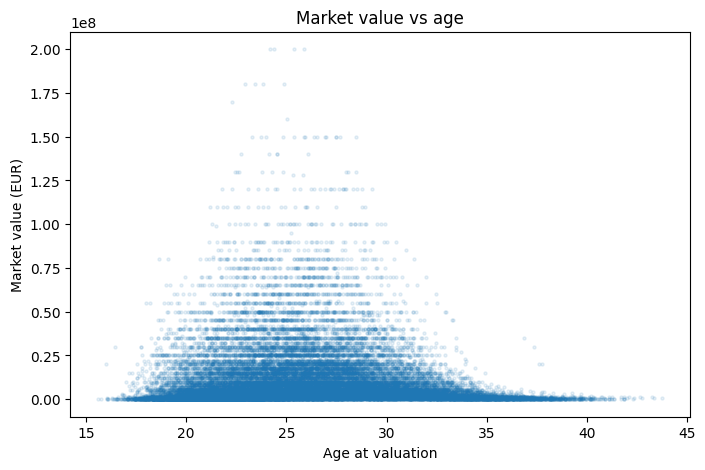

In [4]:
# Age isn't in player_value_history directly -- pull date_of_birth from
# the raw players table and compute age at each valuation date.
players_dob = con.sql("SELECT player_id, date_of_birth FROM raw.players").df()
players_dob['date_of_birth'] = pd.to_datetime(players_dob['date_of_birth'])

vh = value_history.merge(players_dob, on='player_id', how='left')
vh['valuation_date'] = pd.to_datetime(vh['valuation_date'])
vh['age_at_valuation'] = (
    (vh['valuation_date'] - vh['date_of_birth']).dt.days / 365.25
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(vh['age_at_valuation'], vh['market_value_in_eur'], alpha=0.1, s=5)
ax.set_xlabel('Age at valuation')
ax.set_ylabel('Market value (EUR)')
ax.set_title('Market value vs age')
plt.show()

## Injury frequency patterns
By position, age, and workload (total 90s played from FBref) — this is what feeds the risk score design in notebook 03.

In [5]:
injury_workload[['injury_count', 'total_days_missed', 'total_90s_played']].describe()

,injury_count,total_days_missed,total_90s_played
count,2933.000000,2933.0,2933.000000
mean,5.366860,0.0,509.131723
std,8.207433,0.0,1197.145226
min,0.000000,0.0,0.000000
25%,0.000000,0.0,0.000000
50%,3.000000,0.0,0.000000
75%,7.000000,0.0,330.300000
max,60.000000,0.0,9314.466667


## Injury count cap, visualized
Confirming the pagination-cap pattern found earlier -- a spike right at 60 with a steep cliff below it, not a gradual falloff.

In [6]:
injury_workload['injury_count'].value_counts().sort_index(ascending=False).head(20)

injury_count
60    28
53     1
50     1
40     1
38     1
37     2
36     2
35     2
34     2
33     3
32     3
31     3
29     5
28     4
27     5
26     9
25    11
24    12
23    13
22     8
Name: count, dtype: int64

## Notes / decisions made in this notebook
- (fill in as you go — e.g. how you handled zero-injury players, any players dropped for missing data, any surprising outliers worth flagging)

In [7]:
check = con.sql("""
    SELECT player_id, COUNT(DISTINCT player_club_domestic_competition_id) as n_distinct_comps
    FROM raw.player_valuations
    GROUP BY player_id
    HAVING COUNT(DISTINCT player_club_domestic_competition_id) > 1
""").df()
print(len(check))

7890


In [8]:
con.close()  # release the old connection first
con = duckdb.connect('../data/warehouse.duckdb')
print(con.sql("""
    SELECT * FROM main.player_value_history
    WHERE canonical_name = 'Tomas Rosicky'
    ORDER BY valuation_date
""").df())

    player_id canonical_name valuation_date  market_value_in_eur  \
0         132  Tomas Rosicky     2004-10-04             13000000   
1         132  Tomas Rosicky     2005-03-07             11000000   
2         132  Tomas Rosicky     2005-09-04             10000000   
3         132  Tomas Rosicky     2006-01-09             11000000   
4         132  Tomas Rosicky     2007-04-25             14400000   
5         132  Tomas Rosicky     2007-09-01             16500000   
6         132  Tomas Rosicky     2008-02-04             17500000   
7         132  Tomas Rosicky     2008-07-04             17000000   
8         132  Tomas Rosicky     2009-02-23             15500000   
9         132  Tomas Rosicky     2009-06-29             13000000   
10        132  Tomas Rosicky     2010-01-25             11000000   
11        132  Tomas Rosicky     2010-08-13              9500000   
12        132  Tomas Rosicky     2011-02-01              7500000   
13        132  Tomas Rosicky     2011-08-08     

In [3]:
con.close()

In [1]:
import duckdb
con = duckdb.connect('../data/warehouse.duckdb')
print(con.sql("""
    SELECT * FROM main.player_value_history
    WHERE canonical_name = 'Tomas Rosicky'
    ORDER BY valuation_date
""").df())

    player_id canonical_name valuation_date  market_value_in_eur  \
0         132  Tomas Rosicky     2004-10-04             13000000   
1         132  Tomas Rosicky     2005-03-07             11000000   
2         132  Tomas Rosicky     2005-09-04             10000000   
3         132  Tomas Rosicky     2006-01-09             11000000   
4         132  Tomas Rosicky     2007-04-25             14400000   
5         132  Tomas Rosicky     2007-09-01             16500000   
6         132  Tomas Rosicky     2008-02-04             17500000   
7         132  Tomas Rosicky     2008-07-04             17000000   
8         132  Tomas Rosicky     2009-02-23             15500000   
9         132  Tomas Rosicky     2009-06-29             13000000   
10        132  Tomas Rosicky     2010-01-25             11000000   
11        132  Tomas Rosicky     2010-08-13              9500000   
12        132  Tomas Rosicky     2011-02-01              7500000   
13        132  Tomas Rosicky     2011-08-08     

In [2]:
con.close()  # if not already closed
con = duckdb.connect('../data/warehouse.duckdb')

print("Unique players:", con.sql("SELECT COUNT(DISTINCT player_id) FROM main.player_value_history").df())

# spot-check a few more players who are known to have played across leagues
for name in ['Erling Haaland', 'Mohamed Salah', 'Kevin De Bruyne']:
    print(f"\n{name}:")
    print(con.sql(f"""
        SELECT valuation_date, club_name, market_value_in_eur
        FROM main.player_value_history
        WHERE canonical_name = '{name}'
        ORDER BY valuation_date
        LIMIT 5
    """).df())

Unique players:    count(DISTINCT player_id)
0                       1959

Erling Haaland:
  valuation_date          club_name  market_value_in_eur
0     2016-12-18           Bryne FK               200000
1     2017-12-23           Molde FK               300000
2     2018-09-10           Molde FK              2000000
3     2018-12-30           Molde FK              5000000
4     2019-06-03  Red Bull Salzburg              5000000

Mohamed Salah:
  valuation_date        club_name  market_value_in_eur
0     2010-06-06  El Mokawloon SC                25000
1     2011-01-01  El Mokawloon SC                25000
2     2011-05-09  El Mokawloon SC                50000
3     2011-07-14  El Mokawloon SC               150000
4     2011-12-25  El Mokawloon SC               300000

Kevin De Bruyne:
Empty DataFrame
Columns: [valuation_date, club_name, market_value_in_eur]
Index: []
